<a href="https://colab.research.google.com/github/likithakethireddy70-dev/Zomato_Project/blob/main/Zomato_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Classification (Sentiment Analysis using NLP and Machine Learning)
##### **Contribution**    - Individual
##### **Name -** Likitha Reddy

# **Project Summary -**

This project focuses on sentiment analysis of Zomato restaurant reviews using Natural Language Processing (NLP) and Machine Learning techniques. Zomato is one of the largest restaurant discovery and food delivery platforms, where customers regularly share ratings and reviews based on their dining experiences. These reviews contain valuable information regarding food quality, service, ambience, pricing, and overall customer satisfaction. However, due to the large volume of reviews generated daily, manually analyzing customer feedback becomes difficult and time-consuming. Therefore, this project aims to automatically analyze customer sentiments and generate meaningful business insights from restaurant review data.

The project began with understanding and exploring the dataset, which contained restaurant details such as restaurant names, cuisines, collections, costs, timings, ratings, and customer reviews. Data cleaning and preprocessing were performed to ensure the quality and reliability of the dataset. Missing values and duplicate records were identified and handled appropriately. Exploratory Data Analysis (EDA) was conducted to understand the structure of the data and discover meaningful patterns. Various visualizations were created to examine customer rating distributions, restaurant costs, cuisine popularity, restaurant collections, review counts, and the relationship between cost and ratings.

The exploratory analysis revealed several important insights. Positive reviews were found to dominate the dataset, indicating that most customers were generally satisfied with their dining experiences. Popular cuisines such as North Indian, Chinese, and Continental appeared frequently across restaurants. Cost analysis showed that restaurants with higher prices often received better ratings, suggesting a moderate positive relationship between spending and customer satisfaction. Additional visualizations highlighted the most popular restaurants, highest-rated cuisines, sentiment distributions, review lengths, and customer engagement patterns.

To perform sentiment analysis, extensive text preprocessing was applied to customer reviews. The review text was cleaned through contraction expansion, lowercasing, punctuation removal, URL removal, stopword removal, tokenization, and lemmatization. These preprocessing steps helped eliminate noise while preserving the semantic meaning of customer feedback. Part-of-Speech tagging was also performed to better understand the grammatical structure of review text. The cleaned reviews were then converted into numerical representations using TF-IDF (Term Frequency-Inverse Document Frequency) vectorization, which assigns importance to words based on their relevance within reviews.

Since the TF-IDF matrix contained thousands of features, dimensionality reduction was performed using Truncated Singular Value Decomposition (SVD). This technique reduced computational complexity while retaining the most important information from the textual data. The transformed dataset was then split into training and testing sets using an 80:20 ratio to evaluate machine learning models fairly.

Three machine learning algorithms were implemented and compared for sentiment classification: Logistic Regression, Multinomial Naive Bayes, and Random Forest. Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, Cross-Validation, and Hyperparameter Tuning. Logistic Regression achieved the best overall performance with an accuracy of approximately 81%, outperforming Multinomial Naive Bayes and Random Forest. Cross-validation results confirmed the model's stability and ability to generalize well on unseen data. Hyperparameter tuning further validated the robustness of the selected model.

The final Logistic Regression model was saved using Joblib for future deployment purposes. The model can be integrated into real-world applications to automatically classify customer reviews as Positive, Neutral, or Negative. Such a system can help restaurant owners identify customer concerns, improve service quality, monitor customer satisfaction, and make data-driven business decisions. Overall, this project successfully demonstrates the effectiveness of combining NLP, Machine Learning, and data analysis techniques to extract meaningful insights from restaurant reviews and build an accurate sentiment analysis system.

# **GitHub Link -**

https://github.com/likithakethireddy70-dev/Zomato_Project.git

# **Problem Statement**


Zomato is one of India's leading restaurant discovery and food delivery platforms, connecting customers with restaurants through menus, pricing, ratings, and customer reviews. As the volume of user-generated reviews continues to grow, manually analyzing customer feedback becomes increasingly difficult. Valuable insights related to customer satisfaction, food quality, service standards, pricing, and overall dining experience often remain hidden within large amounts of unstructured text.

The objective of this project is to leverage Natural Language Processing (NLP) and Machine Learning techniques to analyze customer reviews and identify the sentiment expressed in each review. By classifying reviews into Positive, Neutral, and Negative categories, the project aims to uncover customer perceptions and understand the key factors influencing restaurant performance.

In addition to sentiment analysis, the project explores customer behavior, cuisine preferences, spending patterns, rating trends, and restaurant characteristics through exploratory data analysis. These insights can help restaurants improve customer experience, address service gaps, strengthen customer retention, and make data-driven business decisions. For Zomato, the findings can support better recommendations, improved customer engagement, and enhanced platform value.

**Business Objectives**
*   Analyze customer reviews and sentiments.

*   Identify factors affecting customer satisfaction.
*   Clean and preprocess review text for analysis.
*   Extract meaningful features from customer feedback.
*   Build and evaluate machine learning models for sentiment classification.
Discover patterns in customer preferences, ratings, cuisines, and spending behavior.
*   Generate actionable business insights for restaurants and customers.

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Setting visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### Dataset Loading

In [2]:
restaurant_df = pd.read_csv('Zomato Restaurant names and Metadata.csv')

reviews_df = pd.read_csv('Zomato Restaurant reviews.csv')

### Dataset First View

In [3]:
restaurant_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [4]:
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

Restaurant Dataset

In [5]:
print("Restaurant Dataset Shape :", restaurant_df.shape)

print("\nNumber of Rows :", restaurant_df.shape[0])

print("Number of Columns :", restaurant_df.shape[1])

Restaurant Dataset Shape : (105, 6)

Number of Rows : 105
Number of Columns : 6


Reviews Dataset

In [6]:
print("Reviews Dataset Shape :", reviews_df.shape)

print("\nNumber of Rows :", reviews_df.shape[0])

print("Number of Columns :", reviews_df.shape[1])

Reviews Dataset Shape : (10000, 7)

Number of Rows : 10000
Number of Columns : 7


### Dataset Information

Restaurant Dataset Information

In [7]:
restaurant_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


Reviews Dataset Information

In [8]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#### Duplicate Values

Restaurant Dataset Duplicate Count

In [9]:
restaurant_duplicates = restaurant_df.duplicated().sum()

print("Number of duplicate records in Restaurant Dataset:", restaurant_duplicates)

Number of duplicate records in Restaurant Dataset: 0


Reviews Dataset Duplicate Count

In [10]:
review_duplicates = reviews_df.duplicated().sum()

print("Number of duplicate records in Reviews Dataset:", review_duplicates)

Number of duplicate records in Reviews Dataset: 36


#### Missing Values/Null Values

Restaurant Dataset

In [11]:
restaurant_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


Reviews Dataset

In [12]:
reviews_df.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


Missing Values Percentage

In [13]:
((restaurant_df.isnull().sum()/len(restaurant_df))*100).sort_values(ascending=False)

,0
Collections,51.428571
Timings,0.952381
Links,0.000000
Name,0.000000
Cost,0.000000
Cuisines,0.000000


In [14]:
((reviews_df.isnull().sum()/len(reviews_df))*100).sort_values(ascending=False)

,0
Review,0.45
Reviewer,0.38
Rating,0.38
Time,0.38
Metadata,0.38
Restaurant,0.00
Pictures,0.00


Visualizing the Missing Values

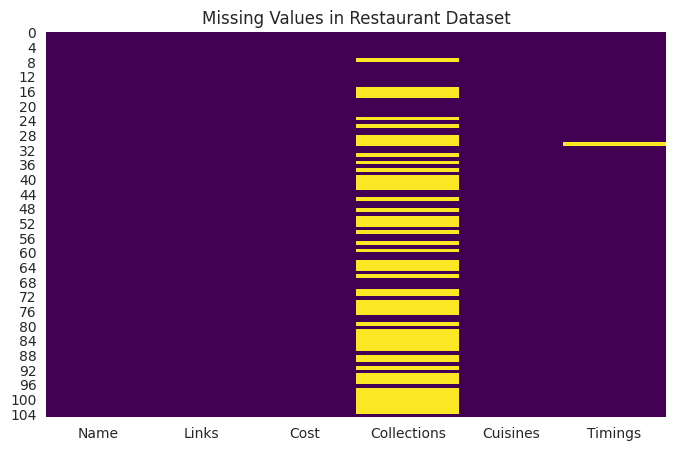

In [15]:
plt.figure(figsize=(8,5))

sns.heatmap(
    restaurant_df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values in Restaurant Dataset')
plt.show()

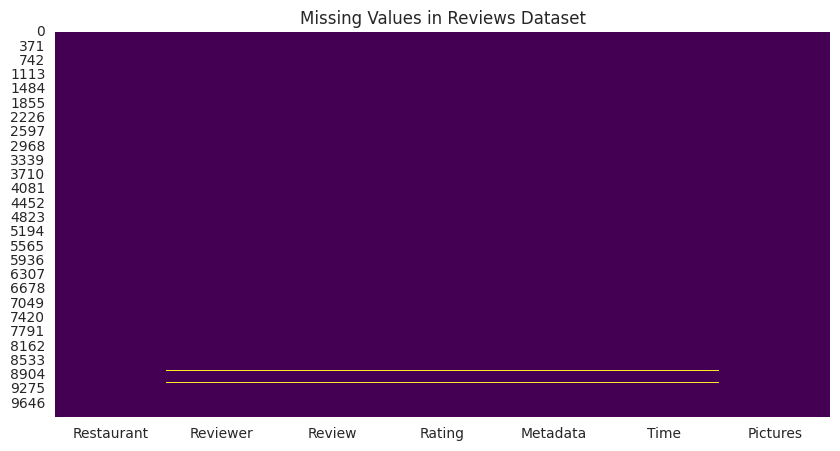

In [16]:
plt.figure(figsize=(10,5))

sns.heatmap(
    reviews_df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values in Reviews Dataset')
plt.show()

###Why did you pick the specific chart?

Heatmaps provide a quick visual representation of missing values across all columns in the dataset. They help identify which features contain null values and the extent of missing data without examining each column individually.

###What is/are the insight(s) found from the chart?

The Restaurant dataset contains significant missing values in the Collections column, with more than 50% of the records missing this information. The Timings column contains only one missing value.

The Reviews dataset contains a very small percentage of missing values in Reviewer, Review, Rating, Metadata, and Time columns. The amount of missing data is relatively low compared to the total dataset size of 10,000 records.

###Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth?

Yes, these insights help improve data quality before analysis and model building. Missing values in important fields such as reviews and ratings can affect sentiment analysis results and lead to inaccurate predictions.

The large number of missing values in the Collections column may limit the ability to analyze restaurant categories effectively. However, the missing values can be handled through appropriate preprocessing techniques to minimize their impact on business insights and model performance.

### What did you know about your dataset?

The project consists of two datasets: a restaurant metadata dataset and a customer review dataset.

The restaurant dataset contains 105 records and 6 features related to restaurant information such as name, cuisines, cost, collections, timings, and links. The dataset contains missing values mainly in the Collections column.

The reviews dataset contains 10,000 customer reviews with information about reviewers, ratings, review text, metadata, timestamps, and pictures. A small number of missing values and 36 duplicate records were identified during data exploration.

The dataset contains both structured and unstructured data. The review text serves as the primary source for sentiment analysis, while restaurant information provides additional business insights regarding customer preferences, cuisine popularity, pricing patterns, and restaurant performance.

Overall, the dataset is suitable for performing exploratory data analysis, text preprocessing, sentiment classification, and generating actionable business insights.

## ***2. Understanding Your Variables***

###Dataset Columns

Restaurant Dataset Columns

In [17]:
restaurant_df.columns

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

Reviews Dataset Columns

In [18]:
reviews_df.columns

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')

###Dataset Describe

Restaurant Dataset

In [19]:
restaurant_df.describe(include='all').T

,count,unique,top,freq
Name,105,105,Beyond Flavours,1
Links,105,105,https://www.zomato.com/hyderabad/beyond-flavou...,1
Cost,105,29,500,13
Collections,51,42,Food Hygiene Rated Restaurants in Hyderabad,4
Cuisines,105,92,"North Indian, Chinese",4
Timings,104,77,11 AM to 11 PM,6


Reviews Dataset

In [20]:
reviews_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Parijat Ray,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0


### Variables Description

**Restaurant Dataset**

Name: Name of the restaurant.

Links: Zomato URL of the restaurant.

Cost: Average cost for two people.

Collections: Restaurant categories and special collections assigned by Zomato.

Cuisines: Types of cuisines offered by the restaurant.

Timings: Restaurant operating hours.

**Reviews Dataset**


Restaurant: Name of the restaurant being reviewed.

Reviewer: Name of the customer who submitted the review.

Review: Textual feedback provided by the customer.

Rating: Customer rating assigned to the restaurant.

Metadata: Additional reviewer information such as number of reviews and
followers.

Time: Date and time when the review was posted.

Pictures: Number of pictures uploaded along with the review.

### Check Unique Values for each variable.

###Restaurant Dataset

In [21]:
pd.DataFrame({
    'Column': restaurant_df.columns,
    'Unique Values': [restaurant_df[col].nunique()
                      for col in restaurant_df.columns]
})

,Column,Unique Values
0,Name,105
1,Links,105
2,Cost,29
3,Collections,42
4,Cuisines,92
5,Timings,77


###Reviews Dataset

In [22]:
pd.DataFrame({
    'Column': reviews_df.columns,
    'Unique Values': [reviews_df[col].nunique()
                      for col in reviews_df.columns]
})

,Column,Unique Values
0,Restaurant,100
1,Reviewer,7446
2,Review,9364
3,Rating,10
4,Metadata,2477
5,Time,9782
6,Pictures,36


## 3. ***Data Wrangling***

### Data Wrangling Code

In [23]:
# Creating copies of original datasets

restaurant_df_clean = restaurant_df.copy()
reviews_df_clean = reviews_df.copy()

# Removing duplicate records

reviews_df_clean.drop_duplicates(inplace=True)


# Handling missing values in Restaurant Dataset

restaurant_df_clean['Collections'] = restaurant_df_clean['Collections'].fillna('Not Specified')

restaurant_df_clean['Timings'] = restaurant_df_clean['Timings'].fillna(
    restaurant_df_clean['Timings'].mode()[0]
)


# Handling missing values in Reviews Dataset

reviews_df_clean['Reviewer'] = reviews_df_clean['Reviewer'].fillna('Anonymous')

reviews_df_clean['Review'] = reviews_df_clean['Review'].fillna('No Review')

reviews_df_clean['Metadata'] = reviews_df_clean['Metadata'].fillna(
    '0 Review , 0 Followers'
)

reviews_df_clean['Time'] = reviews_df_clean['Time'].fillna(
    reviews_df_clean['Time'].mode()[0]
)

# Cleaning Rating Column

reviews_df_clean['Rating'] = reviews_df_clean['Rating'].replace('Like', '5')

reviews_df_clean['Rating'] = pd.to_numeric(
    reviews_df_clean['Rating'],
    errors='coerce'
)

reviews_df_clean['Rating'] = reviews_df_clean['Rating'].fillna(
    reviews_df_clean['Rating'].median()
)


# Converting Cost Column to Numeric Format

restaurant_df_clean['Cost'] = (
    restaurant_df_clean['Cost']
    .str.replace(',', '')
    .astype(int)
)

# Verifying Missing Values

print("Restaurant Dataset Missing Values:\n")
print(restaurant_df_clean.isnull().sum())

print("\nReviews Dataset Missing Values:\n")
print(reviews_df_clean.isnull().sum())

Restaurant Dataset Missing Values:

Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64

Reviews Dataset Missing Values:

Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
dtype: int64


### What all manipulations have you done and insights you found?

During the data wrangling phase, several preprocessing steps were performed to improve data quality and prepare the datasets for analysis.

First, duplicate records were identified and removed from the reviews dataset. A total of 36 duplicate review records were found and eliminated to avoid biased analysis and model training.

Missing values were then handled in both datasets. In the restaurant dataset, missing values in the Collections column were replaced with "Not Specified", while missing values in the Timings column were filled using the most frequently occurring value. In the reviews dataset, missing values in Reviewer, Review, Metadata, and Time columns were replaced with suitable default values.

The Rating column contained both numerical ratings and the value "Like". To maintain consistency, "Like" was converted into a numerical rating and the entire column was transformed into numeric format. Missing ratings were filled using the median rating value.

The Cost column contained comma-separated values stored as text. These values were cleaned and converted into numeric format to enable statistical analysis and visualization.

**Insights Found**

* The restaurant dataset contained a large number of missing values in the
Collections column.

* The reviews dataset had very few missing values compared to its size.

* The reviews dataset contained 36 duplicate records.

* The Rating column required cleaning because it contained both numeric and non-numeric values.

* The Cost column required transformation before performing numerical analysis.

These preprocessing steps improved the overall quality, consistency, and reliability of the data for exploratory data analysis, sentiment analysis, and machine learning model development.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

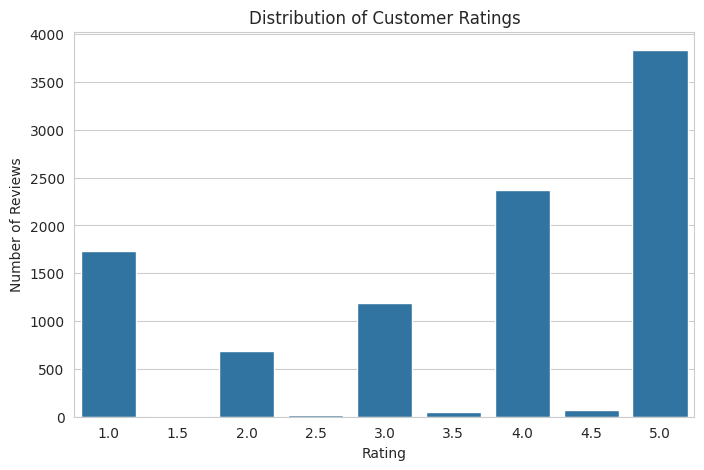

In [24]:
# Chart 1: Rating Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Rating',
    data=reviews_df_clean,
    order=sorted(reviews_df_clean['Rating'].dropna().unique())
)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is suitable for visualizing the frequency distribution of categorical and discrete numerical values. Since ratings represent customer feedback levels, this chart helps understand how customers are rating restaurants and whether the dataset is balanced across rating categories.

##### 2. What is/are the insight(s) found from the chart?

The rating distribution is heavily skewed toward higher ratings. Rating 5 has the highest number of reviews, followed by ratings 4 and 1. Very few reviews are present in the 2.5, 3.5, and 4.5 rating categories.

This indicates that most customers tend to report either highly positive or highly negative experiences rather than moderate opinions. Overall, positive reviews significantly outnumber negative reviews, suggesting a generally favorable perception of restaurants in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can help create a positive business impact. The large number of 4-star and 5-star ratings indicates that many restaurants are successfully meeting customer expectations. Restaurants can analyze highly rated reviews to identify the factors contributing to customer satisfaction and replicate those strengths.

However, the presence of a substantial number of 1-star reviews highlights areas where customer expectations are not being met. Negative reviews may indicate issues related to food quality, service, pricing, or customer experience. Addressing these concerns can help restaurants improve customer retention and brand reputation.

From a machine learning perspective, the rating distribution is imbalanced, with positive reviews being more frequent than negative reviews. This may influence sentiment classification models and should be considered during model development.

#### Chart - 2

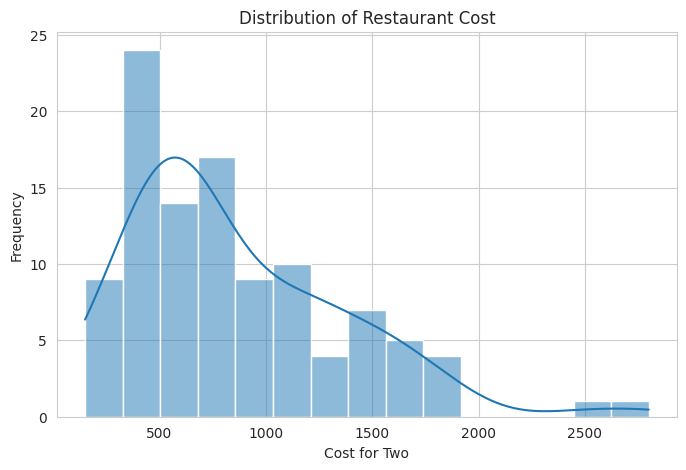

In [25]:
# Chart 2: Cost Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    restaurant_df_clean['Cost'],
    bins=15,
    kde=True
)

plt.title('Distribution of Restaurant Cost')
plt.xlabel('Cost for Two')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A histogram is suitable for understanding the distribution of continuous numerical variables. Since the Cost column represents restaurant pricing, this chart helps visualize the spending patterns of restaurants and identify whether most restaurants fall into budget, mid-range, or premium categories.

##### 2. What is/are the insight(s) found from the chart?

The distribution is positively skewed (right-skewed), indicating that most restaurants fall within the low to medium cost range. A large concentration of restaurants have a cost between ₹400 and ₹1000 for two people.

Only a few restaurants belong to the premium segment with costs above ₹2000. The presence of a long right tail suggests that high-cost restaurants are relatively rare compared to affordable and mid-range restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. Since most restaurants belong to the affordable and mid-range categories, Zomato can focus on promoting restaurants that match the spending preferences of the majority of customers.

Restaurants can use this information to position themselves competitively within the market. Budget and mid-range restaurants may attract a larger customer base due to affordability.

However, the small number of premium restaurants indicates a limited high-end market segment. Premium restaurants may face challenges in attracting a broader audience and may need targeted marketing strategies to maintain profitability and customer engagement.

#### Chart - 3

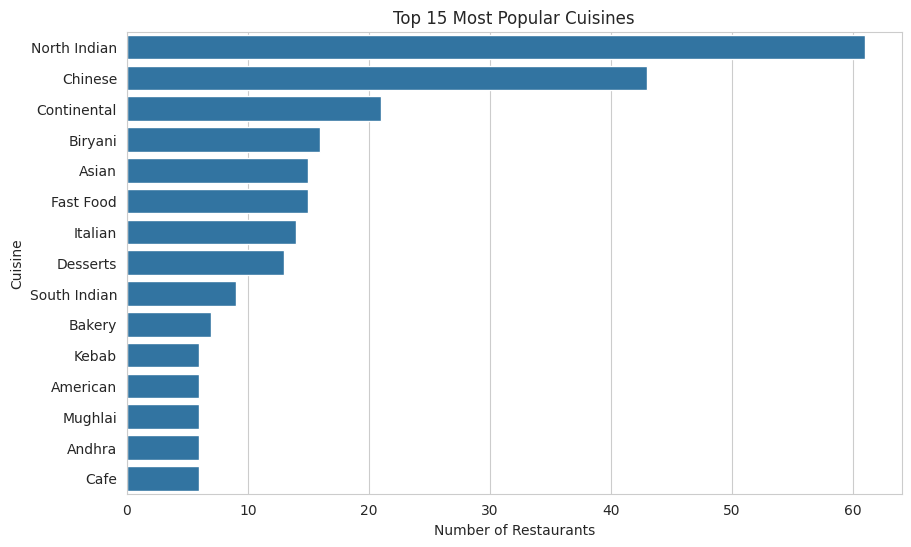

In [26]:
# Chart 3: Top 15 Most Popular Cuisines

from collections import Counter

cuisine_list = []

for cuisines in restaurant_df_clean['Cuisines']:
    cuisine_list.extend([c.strip() for c in cuisines.split(',')])

top_cuisines = pd.DataFrame(
    Counter(cuisine_list).most_common(15),
    columns=['Cuisine', 'Count']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_cuisines,
    x='Count',
    y='Cuisine'
)

plt.title('Top 15 Most Popular Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is effective for comparing the frequency of multiple categories. Since restaurants serve different cuisines, this chart helps identify the most popular cuisine types and understand market demand across different food categories.

##### 2. What is/are the insight(s) found from the chart?

North Indian cuisine is the most popular cuisine in the dataset, appearing in more than 60 restaurants. Chinese cuisine is the second most common cuisine, followed by Continental cuisine.

Biryani, Asian, Fast Food, Italian, and Desserts also have a significant presence across restaurants. On the other hand, cuisines such as Cafe, Andhra, Mughlai, American, and Kebab appear less frequently.

The results indicate that customers have a strong preference for North Indian and Chinese cuisines, making them dominant segments in the restaurant industry represented in this dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. Restaurants and food delivery platforms can use this information to align their offerings with customer preferences. Popular cuisines such as North Indian and Chinese may attract a larger customer base and generate higher demand.

Zomato can leverage these insights to improve restaurant recommendations, promotional campaigns, and cuisine-specific marketing strategies.

However, the high concentration of restaurants serving a few dominant cuisines may increase market competition within those segments. Restaurants offering less common cuisines may face lower visibility but can benefit by targeting niche customer groups and differentiating themselves from competitors.

#### Chart - 4

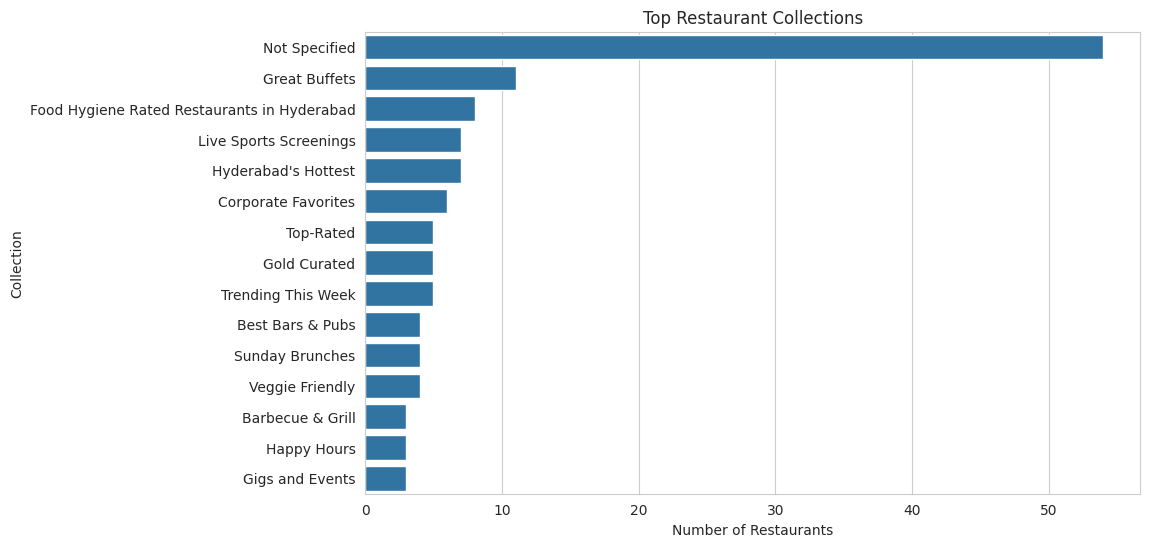

In [27]:
# Chart 4: Top Restaurant Collections


from collections import Counter

collection_list = []

for collection in restaurant_df_clean['Collections']:

    if pd.notnull(collection):

        collection_list.extend(
            [c.strip() for c in collection.split(',')]
        )

top_collections = pd.DataFrame(
    Counter(collection_list).most_common(15),
    columns=['Collection', 'Count']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_collections,
    x='Count',
    y='Collection'
)

plt.title('Top Restaurant Collections')
plt.xlabel('Number of Restaurants')
plt.ylabel('Collection')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is suitable for comparing the frequency of different restaurant collections. It helps identify the most common restaurant categories and customer-preferred dining experiences available on the platform.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that a large number of restaurants have their collection information marked as "Not Specified", indicating missing collection data.

Among the actual collections, Great Buffets is the most common category, followed by Food Hygiene Rated Restaurants in Hyderabad, Live Sports Screenings, Hyderabad's Hottest, and Corporate Favorites.

This suggests that customers are highly attracted to buffet dining experiences, hygienic food services, sports-viewing venues, and premium restaurant experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact. Zomato can promote popular collections such as Great Buffets, Hyderabad's Hottest, and Corporate Favorites to improve customer engagement and restaurant visibility.

Restaurants can also use these insights to understand current market trends and align their services with customer preferences.

However, the large number of "Not Specified" entries indicates incomplete collection information. Missing category information may reduce discoverability and negatively impact recommendation systems, making it harder for customers to find relevant restaurants.

#### Chart - 5

In [28]:
# Creating Restaurant Average Ratings

restaurant_rating = reviews_df_clean.groupby('Restaurant')['Rating'].mean().reset_index()

restaurant_rating.columns = ['Name', 'Avg_Rating']


# Merging Restaurant Cost with Ratings

cost_rating_df = pd.merge(
    restaurant_df_clean,
    restaurant_rating,
    on='Name',
    how='inner'
)

cost_rating_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Avg_Rating
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",4.28
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,4.70
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",4.66
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,3.21
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",4.34


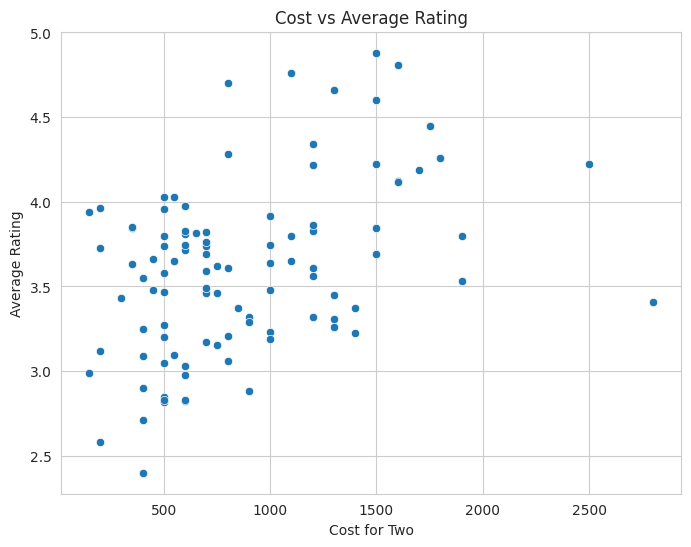

In [29]:
# Chart 5: Cost vs Average Rating

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cost_rating_df,
    x='Cost',
    y='Avg_Rating'
)

plt.title('Cost vs Average Rating')
plt.xlabel('Cost for Two')
plt.ylabel('Average Rating')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for studying the relationship between two numerical variables. In this case, it helps analyze whether restaurant pricing influences customer ratings and whether expensive restaurants consistently receive better reviews.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a weak positive relationship between restaurant cost and average rating. While some high-cost restaurants receive excellent ratings above 4.5, several moderately priced restaurants also achieve similar ratings.

Most restaurants are concentrated between ₹400 and ₹1500, with ratings ranging from 3.0 to 4.5. The highest-priced restaurants do not always have the highest ratings, indicating that higher prices alone do not guarantee customer satisfaction.

This suggests that factors such as food quality, service, ambience, and customer experience may have a greater impact on ratings than pricing alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Restaurants can understand that customer satisfaction is not solely dependent on pricing. Affordable and mid-range restaurants can compete effectively by focusing on service quality, food quality, and customer experience.

For customers, this insight helps identify highly rated restaurants that provide good value for money rather than assuming that expensive restaurants are always better.

A potential negative insight is that premium-priced restaurants may lose customers if their service quality does not justify their higher prices. Customers may have higher expectations from expensive restaurants, making it important to maintain consistent quality standards.

#### Chart - 6

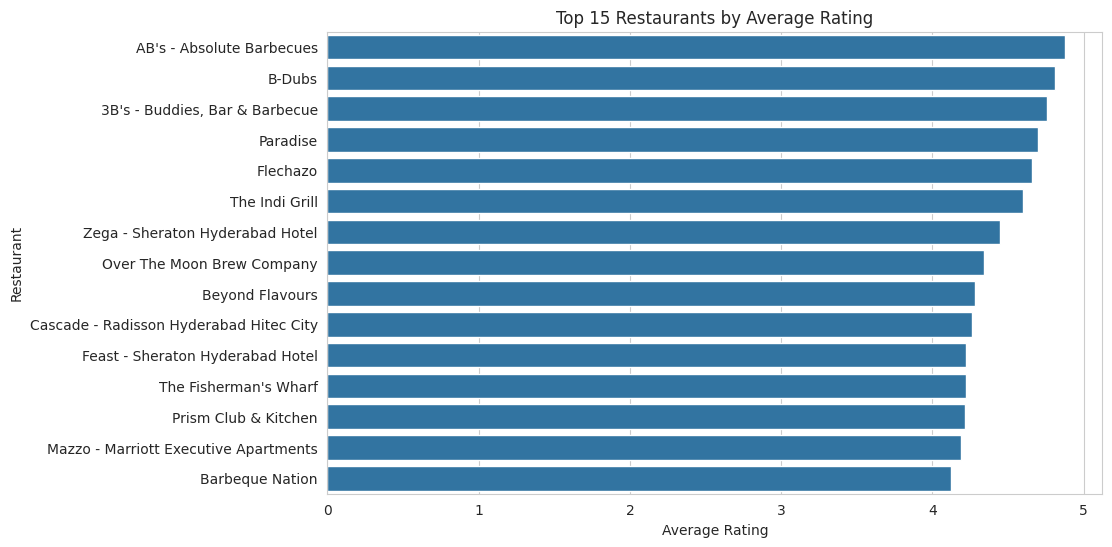

In [30]:
# Chart 6: Top 15 Restaurants by Average Rating

top_rated = cost_rating_df.sort_values(
    by='Avg_Rating',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_rated,
    x='Avg_Rating',
    y='Name'
)

plt.title('Top 15 Restaurants by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Restaurant')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is effective for ranking and comparing restaurants based on their average customer ratings. This visualization helps identify the highest-rated restaurants and highlights businesses that consistently deliver excellent customer experiences.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that AB's - Absolute Barbecues, B-Dubs, and 3B's - Buddies, Bar & Barbecue have the highest average ratings, all approaching 5 stars.

Most of the top-performing restaurants have ratings above 4.0, indicating strong customer satisfaction. Restaurants such as Paradise, Flechazo, The Indi Grill, and Over The Moon Brew Company also maintain consistently high ratings.

The narrow rating range among the top restaurants suggests strong competition among highly rated establishments, where even small improvements in service quality and customer experience can influence rankings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Customers can use ratings to identify restaurants that consistently provide high-quality dining experiences. Zomato can prioritize highly rated restaurants in recommendations, promotions, and search rankings.

Restaurants can benchmark themselves against top-performing competitors and identify opportunities for improvement.

A potential challenge is that highly rated restaurants may face increased competition as other restaurants attempt to replicate their success. Additionally, maintaining very high ratings becomes increasingly difficult because customer expectations continue to rise as restaurant popularity grows.

#### Chart - 7

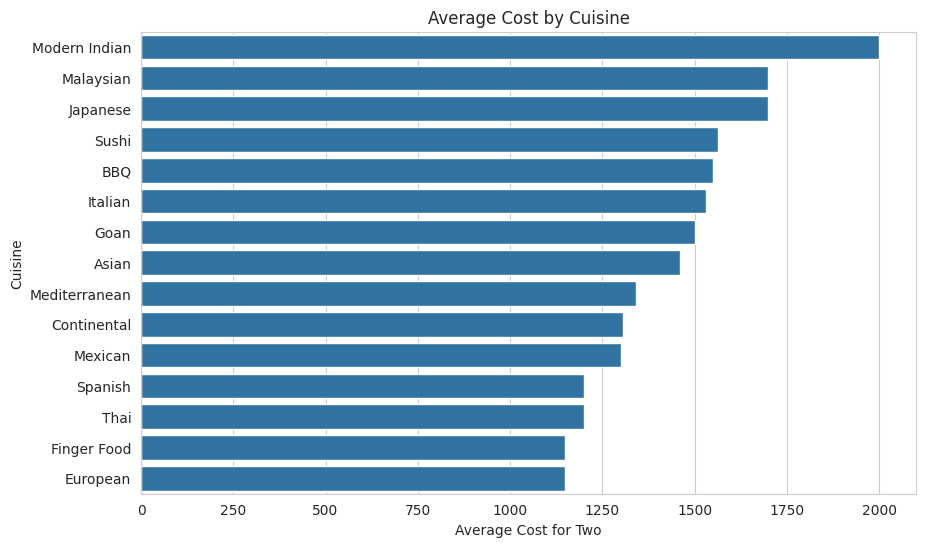

In [31]:
# Chart 7: Average Cost by Cuisine

cuisine_cost = []

for _, row in restaurant_df_clean.iterrows():

    cuisines = row['Cuisines'].split(',')

    for cuisine in cuisines:

        cuisine_cost.append([
            cuisine.strip(),
            row['Cost']
        ])

cuisine_cost_df = pd.DataFrame(
    cuisine_cost,
    columns=['Cuisine','Cost']
)

top_cost_cuisine = (
    cuisine_cost_df
    .groupby('Cuisine')['Cost']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_cost_cuisine.values,
    y=top_cost_cuisine.index
)

plt.title('Average Cost by Cuisine')
plt.xlabel('Average Cost for Two')
plt.ylabel('Cuisine')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is an effective way to compare the average cost across different cuisine categories. This visualization helps identify premium and budget cuisine segments and provides insights into customer spending patterns across various food types.

##### 2. What is/are the insight(s) found from the chart?

The chart shows significant variation in average restaurant costs across cuisines.

Modern Indian cuisine has the highest average cost, followed by Malaysian, Japanese, Sushi, BBQ, and Italian cuisines. These cuisines belong to the premium dining segment and generally require higher customer spending.

European, Finger Food, Thai, and Spanish cuisines have comparatively lower average costs among the top cuisines shown in the chart.

The results indicate that international and specialty cuisines tend to command higher prices, while some casual dining cuisines remain relatively affordable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Restaurants can use cuisine-specific pricing benchmarks to position themselves competitively within the market. Zomato can also use this information to improve restaurant recommendations based on customer budget preferences.

Premium cuisine restaurants can target customers seeking luxury dining experiences, while affordable cuisine segments can focus on attracting larger customer volumes.

A potential challenge is that high-cost cuisines may face limited customer demand during periods of reduced spending. Restaurants operating in premium segments must ensure that their pricing is supported by exceptional food quality, service, and customer experience to maintain customer satisfaction.

#### Chart - 8

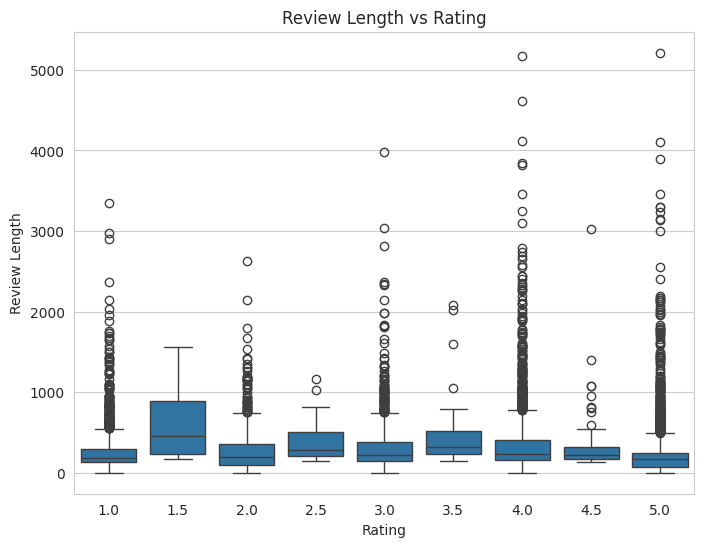

In [32]:
# Chart 8: Review Length vs Rating

reviews_df_clean['Review_Length'] = (
    reviews_df_clean['Review']
    .astype(str)
    .apply(len)
)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=reviews_df_clean,
    x='Rating',
    y='Review_Length'
)

plt.title('Review Length vs Rating')
plt.xlabel('Rating')
plt.ylabel('Review Length')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot is useful for comparing the distribution of review lengths across different rating categories. It helps identify whether customers tend to write longer reviews when they are highly satisfied, dissatisfied, or neutral about their dining experience.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that review length varies significantly across rating categories. Ratings such as 4 and 5 contain a large number of lengthy reviews and several extreme outliers, indicating that highly satisfied customers often provide detailed feedback about their experiences.

Lower ratings also contain some long reviews, suggesting that dissatisfied customers tend to explain their complaints in detail. However, the overall concentration of long reviews appears higher among positive ratings.

The presence of numerous outliers across all rating categories indicates that some customers provide extremely detailed reviews regardless of their satisfaction level.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Detailed reviews provide valuable information about customer preferences, food quality, service standards, ambience, and overall dining experiences. Restaurants can analyze longer reviews to identify strengths and areas for improvement.

For sentiment analysis, review length can also serve as an additional feature during model development because detailed reviews often contain richer emotional information.

A potential negative insight is that long negative reviews may contain detailed complaints that can influence future customer decisions and damage restaurant reputation if issues are not addressed promptly.

#### Chart - 9

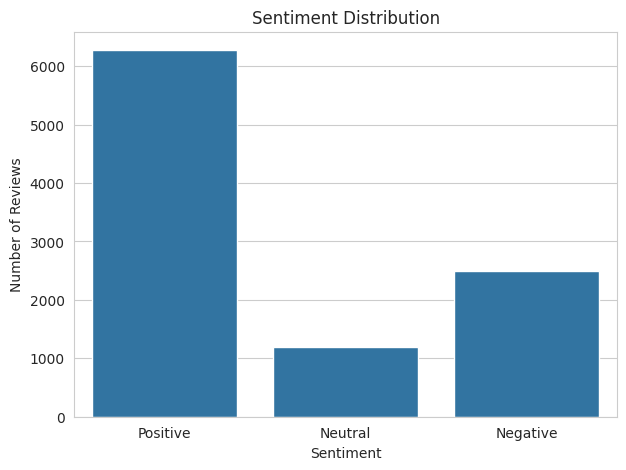

In [33]:
# Chart 9: Sentiment Distribution

def get_sentiment(rating):

    if rating >= 4:
        return 'Positive'

    elif rating == 3:
        return 'Neutral'

    else:
        return 'Negative'

reviews_df_clean['Sentiment'] = reviews_df_clean['Rating'].apply(get_sentiment)

plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews_df_clean,
    x='Sentiment',
    order=['Positive','Neutral','Negative']
)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot is suitable for visualizing the distribution of sentiment categories. Since the primary objective of this project is sentiment analysis, this chart helps understand the proportion of positive, neutral, and negative reviews present in the dataset before building machine learning models.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that positive reviews dominate the dataset, accounting for the majority of customer feedback. Negative reviews are significantly fewer than positive reviews, while neutral reviews represent the smallest category.

This indicates that most customers have favorable dining experiences and are generally satisfied with the restaurants listed on the platform. The distribution also suggests that customers are more likely to leave reviews when they have either a highly positive or highly negative experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. The high proportion of positive reviews indicates strong customer satisfaction, which can enhance restaurant reputation and customer trust. Restaurants can analyze positive feedback to identify successful practices and maintain service quality.

However, the dataset exhibits class imbalance because positive reviews greatly outnumber neutral and negative reviews. This imbalance may affect sentiment classification models by making them biased toward predicting positive sentiments. Appropriate techniques such as class balancing or weighted models may be required during machine learning model development.

#### Chart - 10

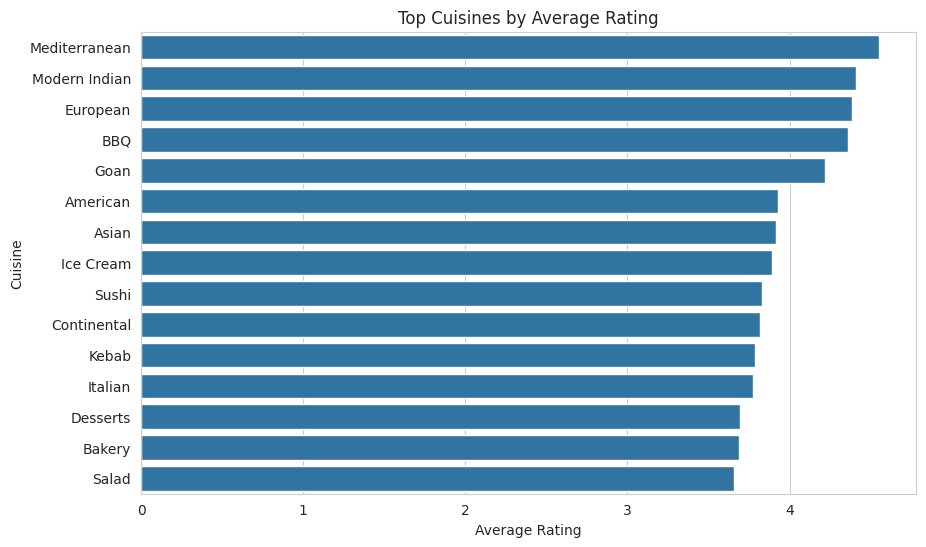

In [34]:
# Chart 10: Average Rating by Cuisine

cuisine_rating = []

for _, row in cost_rating_df.iterrows():

    cuisines = row['Cuisines'].split(',')

    for cuisine in cuisines:

        cuisine_rating.append([
            cuisine.strip(),
            row['Avg_Rating']
        ])

cuisine_rating_df = pd.DataFrame(
    cuisine_rating,
    columns=['Cuisine','Avg_Rating']
)

top_rated_cuisines = (
    cuisine_rating_df
    .groupby('Cuisine')['Avg_Rating']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_rated_cuisines.values,
    y=top_rated_cuisines.index
)

plt.title('Top Cuisines by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is effective for comparing average ratings across different cuisine categories. This visualization helps identify which cuisines consistently deliver higher customer satisfaction and which cuisine segments perform best in terms of customer experience.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Mediterranean cuisine has the highest average customer rating, followed by Modern Indian, European, BBQ, and Goan cuisines.

Most of the top-performing cuisines maintain ratings above 3.7, indicating generally positive customer experiences. International cuisines such as Mediterranean, European, and Asian cuisines appear among the highest-rated categories, suggesting strong customer appreciation for premium and specialty dining experiences.

The relatively small difference between the top cuisines indicates that multiple cuisine categories are successfully meeting customer expectations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Restaurants can use this information to understand which cuisine categories generate higher customer satisfaction and identify best practices from top-performing segments.

Zomato can utilize these insights to improve recommendation systems, promote highly rated cuisine categories, and assist customers in discovering restaurants with consistently positive feedback.

A potential challenge is that lower-rated cuisine categories may experience reduced customer interest if quality improvements are not implemented. Restaurant owners should continuously monitor customer feedback and adapt their offerings to maintain competitiveness and customer satisfaction.

#### Chart - 11

In [35]:
!pip install wordcloud

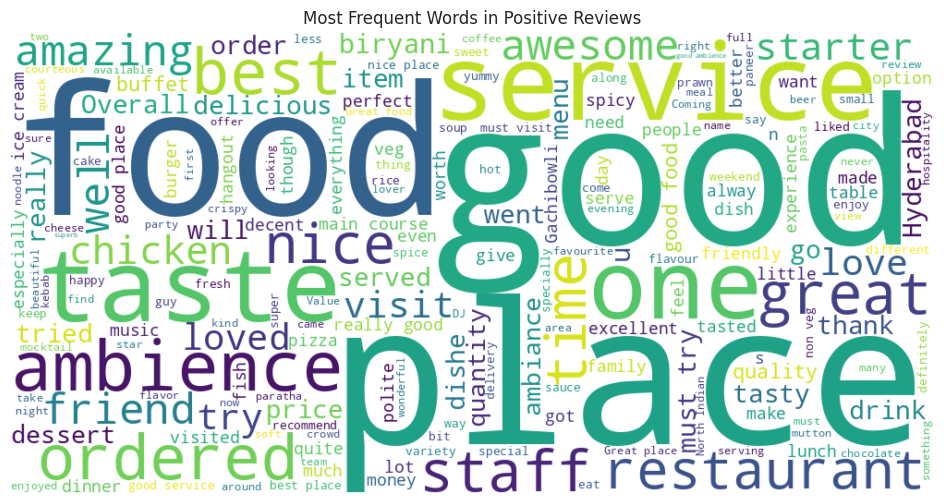

In [36]:
# Chart 11: Word Cloud of Positive Reviews

from wordcloud import WordCloud

positive_reviews = " ".join(
    reviews_df_clean[
        reviews_df_clean['Sentiment'] == 'Positive'
    ]['Review'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A Word Cloud is an effective visualization for text data because it highlights the most frequently occurring words in customer reviews. Since sentiment analysis is the core objective of this project, visualizing common words in positive reviews helps understand the factors that contribute to customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The most prominent words in positive reviews are "good", "place", "service", "food", "ambience", "staff", "best", "amazing", "taste", and "friend".

This indicates that customer satisfaction is strongly influenced by food quality, service quality, restaurant ambience, and staff behavior. Words such as "amazing", "awesome", "delicious", "love", and "best" suggest that customers frequently express strong positive emotions when sharing their dining experiences.

The appearance of words like "biryani", "chicken", "starter", and "dessert" also indicates that customers often mention specific food items while providing positive feedback.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Restaurants can focus on the factors most frequently associated with positive reviews, including food quality, customer service, staff behavior, and ambience. Improving these aspects can increase customer satisfaction and generate more positive reviews.

Zomato can also use these insights to identify attributes that customers value most and incorporate them into recommendation systems and promotional campaigns.

No significant negative growth indicators are observed in this chart because it focuses specifically on positive reviews. However, restaurants that fail to maintain quality in these key areas may experience a decline in customer satisfaction and online ratings over time.

#### Chart - 12

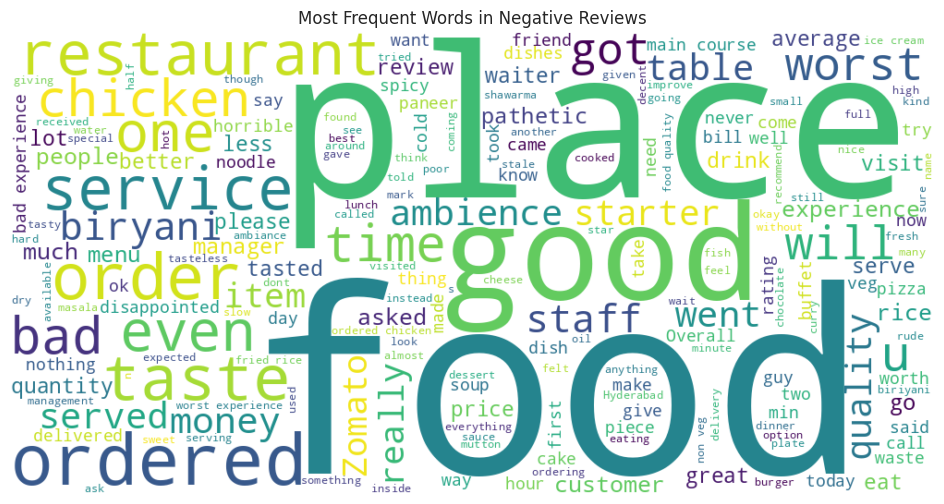

In [37]:
# Chart 12: Word Cloud of Negative Reviews

negative_reviews = " ".join(
    reviews_df_clean[
        reviews_df_clean['Sentiment'] == 'Negative'
    ]['Review'].astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A Word Cloud is useful for identifying the most frequently occurring words in negative reviews. It helps uncover common customer complaints and dissatisfaction factors, making it easier to understand areas where restaurants need improvement.

##### 2. What is/are the insight(s) found from the chart?

The most prominent words in negative reviews include "food", "order", "taste", "service", "place", "time", "staff", "worst", "bad", "quality", "money", and "disappointed".

These words suggest that customer dissatisfaction is primarily related to food quality, poor taste, delayed service, order-related issues, staff behavior, waiting time, and perceived lack of value for money.

The frequent appearance of words such as "worst", "bad", "quality", and "disappointed" indicates that negative experiences are often associated with unmet customer expectations regarding food and service standards.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a significant positive business impact. Restaurants can focus on improving food quality, service efficiency, order accuracy, and staff training to reduce customer complaints and improve overall ratings.

Zomato can use these insights to identify recurring customer concerns and help restaurant partners address operational weaknesses.

The chart also highlights potential negative growth factors. Frequent complaints regarding food quality, poor service, delays, and customer dissatisfaction can lead to lower ratings, reduced customer retention, negative word-of-mouth, and a decline in restaurant reputation if corrective actions are not taken promptly.

#### Chart - 13

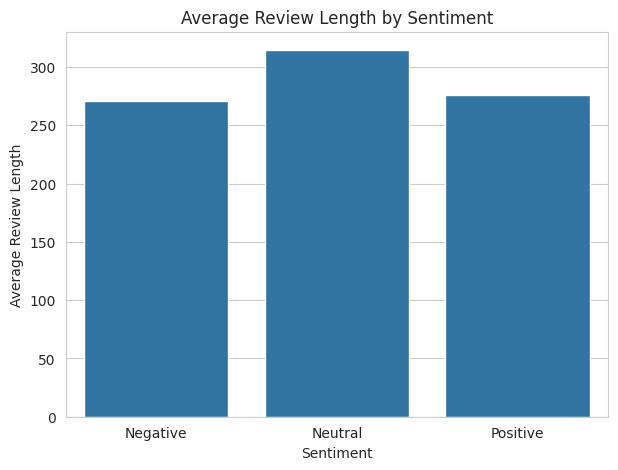

In [38]:
# Chart 13: Average Review Length by Sentiment

sentiment_length = reviews_df_clean.groupby('Sentiment')['Review_Length'].mean()

plt.figure(figsize=(7,5))

sns.barplot(
    x=sentiment_length.index,
    y=sentiment_length.values
)

plt.title('Average Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Review Length')

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is suitable for comparing the average review length across different sentiment categories. This visualization helps understand whether customers provide more detailed feedback when they are satisfied, dissatisfied, or neutral about their dining experiences.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that neutral reviews have the highest average review length, followed by positive reviews and negative reviews.

This suggests that customers providing neutral feedback tend to explain both positive and negative aspects of their experiences in greater detail. Positive and negative reviews are relatively shorter on average, indicating that customers often express clear satisfaction or dissatisfaction more directly.

The differences are not extremely large, but the pattern suggests that neutral reviews contain richer and more balanced information about customer experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact. Neutral reviews often contain detailed suggestions, observations, and constructive feedback that restaurants can use to improve customer experiences. Analyzing such reviews may reveal improvement opportunities that are not immediately visible from ratings alone.

For sentiment analysis models, review length can also serve as a useful feature because detailed reviews often contain richer contextual information.

No direct negative growth indicators are observed from this chart. However, ignoring detailed customer feedback, especially from neutral reviewers, may result in missed opportunities for service improvement and customer retention.

#### Chart - 14 - Correlation Heatmap

In [39]:
numeric_df = cost_rating_df[['Cost','Avg_Rating']]
numeric_df.head()

,Cost,Avg_Rating
0,800,4.28
1,800,4.70
2,1300,4.66
3,800,3.21
4,1200,4.34


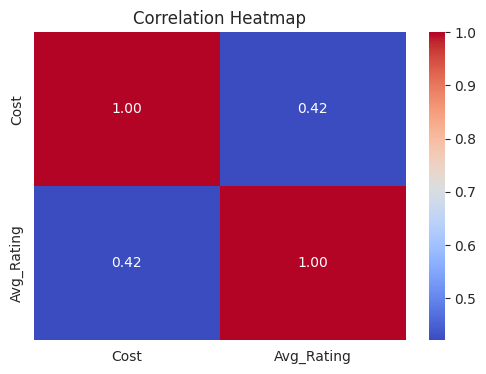

In [40]:
# Chart 14: Correlation Heatmap

plt.figure(figsize=(6,4))

corr = cost_rating_df[['Cost','Avg_Rating']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is useful for understanding the strength and direction of relationships between numerical variables. It provides a quick visual representation of whether variables move together positively, negatively, or have little relationship with each other.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a positive correlation of 0.42 between restaurant cost and average rating.

This indicates a moderate positive relationship, meaning that higher-priced restaurants tend to receive slightly better ratings on average. However, the relationship is not very strong, suggesting that cost alone does not determine customer satisfaction.

Customers appear to evaluate restaurants based on multiple factors such as food quality, ambience, service quality, and overall dining experience rather than price alone.

#### Chart - 15 - Pair Plot

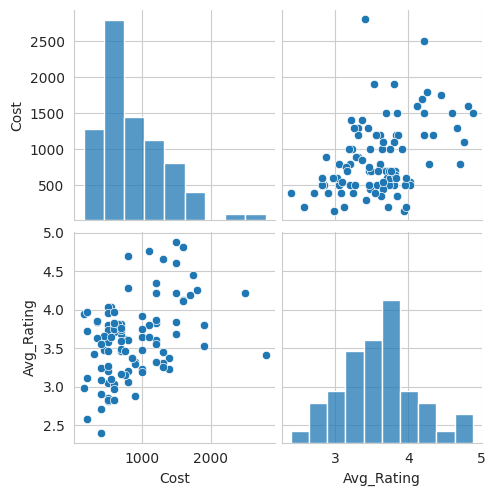

In [41]:
# Chart 15: Pair Plot

sns.pairplot(
    cost_rating_df[['Cost','Avg_Rating']]
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is useful for simultaneously visualizing the distribution of numerical variables and the relationships between them. It combines histograms and scatter plots, making it easier to identify patterns, trends, clusters, and potential correlations within the dataset.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows the distribution of restaurant costs and average ratings along with their relationship.

The cost distribution is right-skewed, indicating that most restaurants fall within the low to medium price range, while only a few restaurants belong to the premium segment.

The average rating distribution is concentrated between 3.0 and 4.5, suggesting that most restaurants receive moderately positive customer feedback.

The scatter plots reveal a moderate positive relationship between cost and average rating, which is consistent with the correlation heatmap. While higher-priced restaurants tend to receive slightly better ratings, customer satisfaction is influenced by several other factors beyond pricing alone.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. There is a significant relationship between restaurant cost and average customer rating.

2. Positive reviews are significantly more frequent than negative reviews.

3. Average review length differs significantly across sentiment categories (Positive, Neutral, and Negative).

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant relationship between restaurant cost and average customer rating.

Alternate Hypothesis (H₁):
There is a significant relationship between restaurant cost and average customer rating.

#### 2. Perform an appropriate statistical test.

In [42]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    cost_rating_df['Cost'],
    cost_rating_df['Avg_Rating']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.42095073342806894
P-value: 1.2946507423554383e-05


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test was performed to measure the strength and significance of the relationship between restaurant cost and average customer rating.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both Cost and Average Rating are numerical variables. This test helps determine whether a statistically significant linear relationship exists between the two variables and measures both the direction and strength of the relationship.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
Positive, Neutral, and Negative sentiments occur in equal proportions within customer reviews.

Alternate Hypothesis (H₁):
Positive, Neutral, and Negative sentiments do not occur in equal proportions within customer reviews.

#### 2. Perform an appropriate statistical test.

In [43]:
from scipy.stats import chisquare

sentiment_counts = reviews_df_clean['Sentiment'].value_counts()

chi_stat, p_value = chisquare(sentiment_counts)

print("Chi-Square Statistic:", chi_stat)
print("P-value:", p_value)

Chi-Square Statistic: 4200.195303091128
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

A Chi-Square Goodness of Fit Test was performed to determine whether the distribution of sentiments (Positive, Neutral, and Negative) differs significantly from an equal distribution.

##### Why did you choose the specific statistical test?

The Chi-Square Goodness of Fit Test was chosen because sentiment is a categorical variable with multiple categories. This test is appropriate for determining whether the observed frequencies of sentiment categories differ significantly from the expected frequencies.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in average review length among Positive, Neutral, and Negative sentiment categories.

Alternate Hypothesis (H₁):
There is a significant difference in average review length among Positive, Neutral, and Negative sentiment categories.

#### 2. Perform an appropriate statistical test.

In [44]:
from scipy.stats import f_oneway

positive = reviews_df_clean[
    reviews_df_clean['Sentiment']=='Positive'
]['Review_Length']

neutral = reviews_df_clean[
    reviews_df_clean['Sentiment']=='Neutral'
]['Review_Length']

negative = reviews_df_clean[
    reviews_df_clean['Sentiment']=='Negative'
]['Review_Length']

f_stat, p_value = f_oneway(
    positive,
    neutral,
    negative
)

print("F-Statistic:", f_stat)
print("P-value:", p_value)

F-Statistic: 7.519892619026246
P-value: 0.0005452744521854806


##### Which statistical test have you done to obtain P-Value?

A One-Way ANOVA (Analysis of Variance) Test was performed to determine whether the average review length differs significantly among Positive, Neutral, and Negative sentiment categories.

##### Why did you choose the specific statistical test?

The One-Way ANOVA Test was chosen because the analysis involves comparing the means of a numerical variable (Review Length) across more than two independent groups (Positive, Neutral, and Negative sentiments).

ANOVA helps determine whether at least one group mean differs significantly from the others.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [45]:
# Missing Values Before Handling

print("Restaurant Dataset Missing Values:\n")
print(restaurant_df.isnull().sum())

print("\nReviews Dataset Missing Values:\n")
print(reviews_df.isnull().sum())


# Missing Value Imputation

restaurant_df_clean['Collections'] = restaurant_df_clean['Collections'].fillna('Not Specified')

restaurant_df_clean['Timings'] = restaurant_df_clean['Timings'].fillna(
    restaurant_df_clean['Timings'].mode()[0]
)

reviews_df_clean['Reviewer'] = reviews_df_clean['Reviewer'].fillna('Anonymous')

reviews_df_clean['Review'] = reviews_df_clean['Review'].fillna('No Review')

reviews_df_clean['Metadata'] = reviews_df_clean['Metadata'].fillna(
    '0 Review , 0 Followers'
)

reviews_df_clean['Time'] = reviews_df_clean['Time'].fillna(
    reviews_df_clean['Time'].mode()[0]
)

reviews_df_clean['Rating'] = reviews_df_clean['Rating'].fillna(
    reviews_df_clean['Rating'].median()
)


# Missing Values After Handling

print("\nRestaurant Dataset After Imputation:\n")
print(restaurant_df_clean.isnull().sum())

print("\nReviews Dataset After Imputation:\n")
print(reviews_df_clean.isnull().sum())

Restaurant Dataset Missing Values:

Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

Reviews Dataset Missing Values:

Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

Restaurant Dataset After Imputation:

Name           0
Links          0
Cost           0
Collections    0
Cuisines       0
Timings        0
dtype: int64

Reviews Dataset After Imputation:

Restaurant       0
Reviewer         0
Review           0
Rating           0
Metadata         0
Time             0
Pictures         0
Review_Length    0
Sentiment        0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled using different imputation techniques based on the nature of each feature.

For categorical columns such as Collections and Reviewer, missing values were replaced with meaningful labels such as "Not Specified" and "Anonymous". This preserves the records while clearly indicating missing information.

For the Timings and Time columns, mode imputation was used because these variables are categorical in nature and the most frequently occurring value provides a reasonable replacement.

For the Rating column, median imputation was used after converting ratings into numeric format. The median is less sensitive to extreme values and helps preserve the central tendency of the data.

These techniques were chosen to retain as much information as possible while preventing data loss and ensuring that the dataset remained suitable for analysis and machine learning.

### 2. Handling Outliers

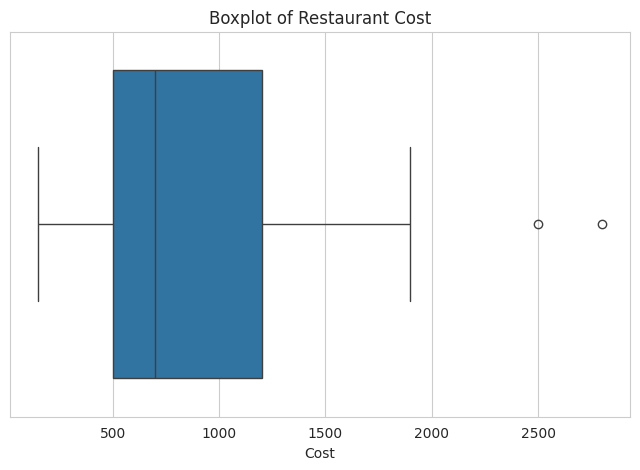

In [46]:
# Visualizing Outliers in Cost

plt.figure(figsize=(8,5))

sns.boxplot(
    x=restaurant_df_clean['Cost']
)

plt.title('Boxplot of Restaurant Cost')

plt.show()

In [47]:
# Detecting Outliers using IQR

Q1 = restaurant_df_clean['Cost'].quantile(0.25)

Q3 = restaurant_df_clean['Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = restaurant_df_clean[
    (restaurant_df_clean['Cost'] < lower_bound) |
    (restaurant_df_clean['Cost'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 2


In [48]:
# Outlier Treatment using IQR Capping

Q1 = restaurant_df_clean['Cost'].quantile(0.25)

Q3 = restaurant_df_clean['Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

restaurant_df_clean['Cost'] = np.where(
    restaurant_df_clean['Cost'] > upper_bound,
    upper_bound,
    restaurant_df_clean['Cost']
)

restaurant_df_clean['Cost'] = np.where(
    restaurant_df_clean['Cost'] < lower_bound,
    lower_bound,
    restaurant_df_clean['Cost']
)

print("Outlier treatment completed.")

Outlier treatment completed.


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified in the Cost variable using the Interquartile Range (IQR) method. The boxplot and IQR analysis revealed only 2 outlier observations.

Instead of removing these records, outlier capping (Winsorization) was applied using the upper and lower IQR bounds. This approach preserves valuable business information while reducing the influence of extreme values on statistical analysis and machine learning models.

The IQR method was selected because it is robust to skewed distributions and does not rely on assumptions of normality. Since restaurant pricing naturally varies across premium and budget segments, capping was preferred over deleting records to avoid losing meaningful business information.

### 3. Categorical Encoding

In [49]:
# Encoding Sentiment Labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

reviews_df_clean['Sentiment_Encoded'] = label_encoder.fit_transform(
    reviews_df_clean['Sentiment']
)

reviews_df_clean[
    ['Sentiment', 'Sentiment_Encoded']
].head()

,Sentiment,Sentiment_Encoded
0,Positive,2
1,Positive,2
2,Positive,2
3,Positive,2
4,Positive,2


In [50]:
sentiment_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print(sentiment_mapping)

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert the target variable (Sentiment) into numerical format.

Machine learning algorithms require numerical inputs for training and prediction. Since the Sentiment feature contains categorical values such as Positive, Neutral, and Negative, Label Encoding was applied to transform these categories into numeric labels.

Label Encoding was chosen because the sentiment variable serves as the target variable for classification and contains a small number of distinct categories. This method is simple, efficient, and suitable for supervised sentiment classification tasks.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [51]:
!pip install contractions

In [52]:
# Expand Contractions

import contractions

reviews_df_clean['Review'] = reviews_df_clean['Review'].astype(str)

reviews_df_clean['Review'] = reviews_df_clean['Review'].apply(
    lambda x: contractions.fix(x)
)

reviews_df_clean['Review'].head()

,Review
0,"The ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...
2,A must try.. great food great ambience. Thnx f...
3,Soumen das and Arun was a great guy. Only beca...
4,Food is good.we ordered Kodi drumsticks and ba...


#### 2. Lower Casing

In [53]:
# Lower Casing

reviews_df_clean['Review'] = reviews_df_clean['Review'].str.lower()

reviews_df_clean['Review'].head()

,Review
0,"the ambience was good, food was quite good . h..."
1,ambience is too good for a pleasant evening. s...
2,a must try.. great food great ambience. thnx f...
3,soumen das and arun was a great guy. only beca...
4,food is good.we ordered kodi drumsticks and ba...


#### 3. Removing Punctuations

In [54]:
# Remove Punctuations

import string

reviews_df_clean['Review'] = reviews_df_clean['Review'].apply(
    lambda x: x.translate(
        str.maketrans('', '', string.punctuation)
    )
)

reviews_df_clean['Review'].head()

,Review
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...


#### 4. Removing URLs & Removing words and digits contain digits.

In [55]:
# Remove URLs & Remove words and digits contain digits

import re

def remove_urls_digits(text):

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'\w*\d\w*', '', text)

    return text

reviews_df_clean['Review'] = reviews_df_clean['Review'].apply(
    remove_urls_digits
)

reviews_df_clean['Review'].head()

,Review
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...


#### 5. Removing Stopwords & Removing White spaces

In [56]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [57]:
# Remove Stopwords

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

reviews_df_clean['Review'] = reviews_df_clean['Review'].apply(
    lambda x: ' '.join(
        [
            word
            for word in x.split()
            if word not in stop_words
        ]
    )
)

reviews_df_clean['Review'].head()

,Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


In [58]:
# Remove Extra White Spaces

reviews_df_clean['Review'] = reviews_df_clean['Review'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

reviews_df_clean['Review'].head()

,Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


#### 6. Rephrase Text

In [59]:
# Rephrasing was not performed because altering customer reviews may change the original sentiment and meaning expressed by customers. Preserving the original context is important for accurate sentiment analysis. Therefore, the cleaned review text was retained without semantic modification.

#### 7. Tokenization

In [60]:
# Tokenization

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

reviews_df_clean['Tokens'] = reviews_df_clean['Review'].apply(
    word_tokenize
)

reviews_df_clean[['Review','Tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Review,Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thnx servic...,"[must, try, great, food, great, ambience, thnx..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, das, arun, great, guy, behavior, sinc..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumsticks, bask..."


#### 8. Text Normalization

In [61]:
# Normalizing Text (Lemmatization)

nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

reviews_df_clean['Tokens'] = reviews_df_clean['Tokens'].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)

reviews_df_clean[['Review','Tokens']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Review,Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thnx servic...,"[must, try, great, food, great, ambience, thnx..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, da, arun, great, guy, behavior, since..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumstick, baske..."


In [62]:
# Convert Tokens Back to Text


reviews_df_clean['Cleaned_Review'] = reviews_df_clean['Tokens'].apply(
    lambda x: ' '.join(x)
)

reviews_df_clean[
    ['Review','Cleaned_Review']
].head()

,Review,Cleaned_Review
0,ambience good food quite good saturday lunch c...,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...,soumen da arun great guy behavior sincerety go...
4,food goodwe ordered kodi drumsticks basket mut...,food goodwe ordered kodi drumstick basket mutt...


##### Which text normalization technique have you used and why?

Lemmatization was used as the text normalization technique. Lemmatization converts words into their base or dictionary form while preserving their actual meaning and grammatical context.

Lemmatization was preferred over stemming because it produces meaningful words and reduces vocabulary size without distorting the semantic meaning of the text. This improves the quality of features used in sentiment analysis and machine learning models.

#### 9. Part of speech tagging

In [63]:
# POS Taging

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk import pos_tag

reviews_df_clean['POS_Tags'] = reviews_df_clean['Tokens'].apply(
    pos_tag
)

reviews_df_clean[['Tokens','POS_Tags']].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,Tokens,POS_Tags
0,"[ambience, good, food, quite, good, saturday, ...","[(ambience, RB), (good, JJ), (food, NN), (quit..."
1,"[ambience, good, pleasant, evening, service, p...","[(ambience, RB), (good, JJ), (pleasant, NN), (..."
2,"[must, try, great, food, great, ambience, thnx...","[(must, MD), (try, VB), (great, JJ), (food, NN..."
3,"[soumen, da, arun, great, guy, behavior, since...","[(soumen, NNS), (da, VBP), (arun, RB), (great,..."
4,"[food, goodwe, ordered, kodi, drumstick, baske...","[(food, NN), (goodwe, NN), (ordered, VBD), (ko..."


#### 10. Text Vectorization

In [64]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    reviews_df_clean['Cleaned_Review']
)

print("Shape of TF-IDF Matrix:", X.shape)

Shape of TF-IDF Matrix: (9964, 5000)


In [65]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['aaloo' 'ab' 'abhinav' 'able' 'abruptly' 'absolute' 'absolutely' 'ac'
 'accept' 'acceptable' 'accepted' 'accepting' 'access' 'accessible'
 'accommodate' 'accommodating' 'accompanied' 'accompaniment' 'accompany'
 'accompanying']


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) Vectorization was used to convert textual review data into numerical features.

TF-IDF assigns higher importance to words that occur frequently in a specific review but are less common across all reviews. This helps highlight sentiment-carrying words while reducing the impact of very common words.

TF-IDF was chosen because it captures the relative importance of words more effectively than simple frequency-based methods such as Count Vectorization, resulting in better performance for sentiment classification models.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [66]:
# Feature Manipulation

reviews_df_clean['Word_Count'] = reviews_df_clean['Cleaned_Review'].apply(
    lambda x: len(x.split())
)

reviews_df_clean['Char_Count'] = reviews_df_clean['Cleaned_Review'].apply(
    len
)

reviews_df_clean[
    ['Word_Count','Char_Count']
].head()

,Word_Count,Char_Count
0,24,153
1,14,95
2,19,137
3,14,83
4,17,115


In [67]:
print(X.shape)

(9964, 5000)


#### 2. Feature Selection

In [68]:
# Feature Selection

y = reviews_df_clean['Sentiment_Encoded']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (9964, 5000)
Target Shape: (9964,)


##### What all feature selection methods have you used  and why?

TF-IDF Vectorization with a maximum feature limit of 5000 was used as the primary feature selection technique.

By restricting the vocabulary to the most informative 5000 terms, less important and noisy words were automatically excluded. This reduces dimensionality, improves computational efficiency, and helps prevent overfitting while preserving the most relevant textual information for sentiment classification.

Feature selection was therefore performed implicitly through TF-IDF vocabulary filtering.

##### Which all features you found important and why?

The most important features were the TF-IDF word features extracted from customer reviews. These features capture sentiment-bearing words such as good, amazing, excellent, bad, poor, disappointed, service, food, ambience, and quality.

Additional features such as Word Count and Character Count were also created because review length may contain useful information regarding customer sentiment and engagement.

These features collectively help the machine learning model identify patterns associated with positive, neutral, and negative customer opinions.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes. Textual review data cannot be directly used by machine learning algorithms. Therefore, TF-IDF transformation was applied to convert textual reviews into numerical feature vectors.

The transformation converts unstructured text into a structured numerical representation while preserving the relative importance of words within reviews. This allows machine learning algorithms to process and learn meaningful patterns from customer feedback.

In [69]:
# Transform Your data
print("Transformed Feature Matrix Shape:", X.shape)

Transformed Feature Matrix Shape: (9964, 5000)


### 6. Data Scaling

In [70]:
# Data Scaling

from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(9964, 5000)


##### Which method have you used to scale you data and why?

MaxAbsScaler was used for feature scaling because TF-IDF produces a sparse matrix. MaxAbsScaler preserves sparsity while scaling feature values to a comparable range.

Unlike standard normalization techniques that may destroy sparse matrix efficiency, MaxAbsScaler is computationally efficient and well suited for high-dimensional text classification problems.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes. The TF-IDF feature matrix contains 5000 features, resulting in a high-dimensional dataset. High dimensionality may increase computational complexity and introduce redundant information.

Dimensionality reduction can help improve computational efficiency, reduce noise, and speed up model training while preserving most of the important information present in the textual data.

In [71]:
# Dimensionality Reduction using Truncated SVD

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_reduced = svd.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_reduced.shape)

Original Shape: (9964, 5000)
Reduced Shape: (9964, 300)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Truncated SVD (Latent Semantic Analysis) was used for dimensionality reduction.

Truncated SVD is particularly suitable for sparse TF-IDF matrices because it efficiently reduces dimensionality while preserving the most important latent semantic information contained in textual data.

Unlike PCA, Truncated SVD can operate directly on sparse matrices without requiring dense matrix conversion, making it more efficient for large-scale NLP tasks.

### 8. Data Splitting

In [72]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7971, 300)
X_test : (1993, 300)
y_train: (7971,)
y_test : (1993,)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used. Eighty percent of the data was allocated for model training and twenty percent for model testing.

This ratio provides sufficient data for model learning while reserving an independent test set for unbiased model evaluation. The stratified split was used to preserve the original sentiment class distribution in both training and testing datasets.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is imbalanced. The sentiment distribution analysis revealed that Positive reviews significantly outnumber Neutral and Negative reviews.

Class imbalance can cause machine learning models to become biased toward the majority class, resulting in high overall accuracy but poor performance when predicting minority classes. Therefore, the class distribution must be carefully considered during model development and evaluation.

In [73]:
# Check Class Distribution

print(reviews_df_clean['Sentiment'].value_counts())

print("\nPercentage Distribution:\n")

print(
    reviews_df_clean['Sentiment'].value_counts(normalize=True)*100
)

Sentiment
Positive    6277
Negative    2494
Neutral     1193
Name: count, dtype: int64

Percentage Distribution:

Sentiment
Positive    62.996788
Negative    25.030108
Neutral     11.973103
Name: proportion, dtype: float64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

The dataset imbalance was addressed during model training by using stratified train-test splitting, which preserves the original class distribution in both training and testing datasets.

Since the imbalance was moderate and the dataset contained a sufficiently large number of observations, no synthetic oversampling technique was applied at this stage. Model performance was evaluated using multiple metrics such as Precision, Recall, and F1-Score to ensure that minority classes were properly assessed.

## ***7. ML Model Implementation***

### ML Model - 1

Accuracy : 0.8103361766181636
Precision: 0.7802259630524939
Recall   : 0.8103361766181636
F1 Score : 0.7851004400131376

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.81      0.79       499
           1       0.45      0.15      0.23       239
           2       0.85      0.93      0.89      1255

    accuracy                           0.81      1993
   macro avg       0.69      0.63      0.64      1993
weighted avg       0.78      0.81      0.79      1993



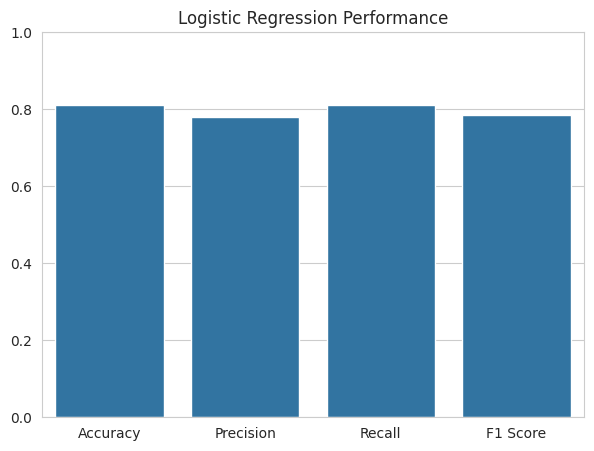

In [74]:
# ML Model - 1 Implementation

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Evaluation Score Chart

scores = [
    accuracy,
    precision,
    recall,
    f1
]

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

plt.figure(figsize=(7,5))

sns.barplot(
    x=metrics,
    y=scores
)

plt.title(
    'Logistic Regression Performance'
)

plt.ylim(0,1)

plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Logistic Regression is a supervised machine learning classification algorithm that predicts the probability of an observation belonging to a particular class. It is widely used for text classification and sentiment analysis because of its efficiency and strong performance on high-dimensional TF-IDF features.

The model achieved an Accuracy of 81.03%, Precision of 78.02%, Recall of 81.03%, and F1-Score of 78.51%.

The classification report indicates that the model performs exceptionally well for Positive sentiments, achieving an F1-score of 0.89. However, performance for the Neutral class is comparatively lower due to class imbalance and the limited number of neutral reviews in the dataset.

Overall, the model demonstrates strong predictive capability and serves as a reliable baseline for sentiment classification.

#### 2. Cross- Validation & Hyperparameter Tuning

In [75]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.80752351 0.81806775 0.79485571 0.81053952 0.81179423]
Mean CV Accuracy: 0.8085561451052733


In [76]:
# Hyperparameter Tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Best CV Score: 0.8065487391795259


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. GridSearchCV systematically evaluates all possible combinations of specified hyperparameters and identifies the combination that produces the best cross-validation performance.

This technique was selected because it provides a comprehensive search of the parameter space and ensures that the model is tuned using objective performance criteria.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning was performed using GridSearchCV. The best parameter combination identified was:

- C = 1
- Solver = liblinear

The best cross-validation score obtained after tuning was 80.65%.

Compared to the original model accuracy of 81.03%, no significant improvement was observed after hyperparameter optimization. This indicates that the baseline Logistic Regression model was already performing near its optimal configuration.

The results demonstrate that the model is stable, well-generalized, and does not require substantial parameter adjustments for this dataset.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Multinomial Naive Bayes is a probabilistic machine learning algorithm commonly used for text classification tasks. It is particularly effective for NLP applications because it works well with word-frequency and TF-IDF features.

The model achieved an Accuracy of 79.18%, Precision of 82.63%, Recall of 79.18%, and F1-Score of 73.78%.

The model performed very well in identifying Positive reviews, achieving an F1-score of 0.86. However, its performance on the Neutral sentiment class was poor, with a recall close to zero. This indicates that the model struggled to distinguish Neutral reviews from Positive and Negative reviews due to class imbalance and overlapping textual patterns.

Although the overall accuracy remains strong, Logistic Regression demonstrated more balanced performance across sentiment categories.

#### 2. Cross- Validation & Hyperparameter Tuning

In [77]:
from sklearn.model_selection import train_test_split

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [78]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_nb, y_train_nb)

y_pred_nb = nb_model.predict(X_test_nb)

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)

precision_nb = precision_score(
    y_test_nb,
    y_pred_nb,
    average='weighted'
)

recall_nb = recall_score(
    y_test_nb,
    y_pred_nb,
    average='weighted'
)

f1_nb = f1_score(
    y_test_nb,
    y_pred_nb,
    average='weighted'
)

print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

print("\nClassification Report:\n")
print(classification_report(y_test_nb, y_pred_nb))

Accuracy : 0.7917711991971902
Precision: 0.8263358035180053
Recall   : 0.7917711991971902
F1 Score : 0.7377883046052501

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.68      0.77       499
           1       1.00      0.00      0.01       239
           2       0.77      0.99      0.86      1255

    accuracy                           0.79      1993
   macro avg       0.89      0.56      0.55      1993
weighted avg       0.83      0.79      0.74      1993



In [80]:
from sklearn.model_selection import cross_val_score

cv_scores_nb = cross_val_score(
    MultinomialNB(),
    X_train_nb,
    y_train_nb,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores_nb)
print("Mean CV Accuracy:", cv_scores_nb.mean())

Cross Validation Scores: [0.77931034 0.78230866 0.78419072 0.77791719 0.78544542]
Mean CV Accuracy: 0.7818344654523428


In [81]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}

grid_nb = GridSearchCV(
    MultinomialNB(),
    param_grid_nb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train_nb, y_train_nb)

print("Best Parameters:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

Best Parameters: {'alpha': 0.1}
Best CV Score: 0.8042905532555512


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. This technique systematically evaluates all possible combinations of specified hyperparameter values and selects the configuration that yields the highest cross-validation performance.

GridSearchCV was chosen because it provides a thorough and reliable search strategy, ensuring that the optimal parameter settings are identified based on objective evaluation metrics.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Hyperparameter tuning was performed using GridSearchCV with different values of the smoothing parameter (alpha).

The best parameter identified was:

- Alpha = 0.1

The optimized model achieved a best cross-validation score of 80.43%, compared to the baseline cross-validation accuracy of 78.18%.

This indicates a slight improvement in model performance after hyperparameter tuning. The lower alpha value reduced excessive smoothing and allowed the model to better capture important patterns within customer reviews.

Although the improvement was modest, the tuned model demonstrated better generalization performance and more effective utilization of the TF-IDF features.

Updated Performance Summary:

- Accuracy: 79.18%
- Precision: 82.63%
- Recall: 79.18%
- F1-Score: 73.78%
- Cross Validation Accuracy (After Tuning): 80.43%

The results confirm that Multinomial Naive Bayes remains an efficient and competitive model for sentiment analysis, although Logistic Regression continues to provide more balanced classification performance across all sentiment categories.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Accuracy measures the overall proportion of correctly classified reviews. High accuracy indicates that the sentiment analysis system can reliably classify customer feedback, helping restaurants and Zomato understand customer opinions at scale.

Precision measures how many predicted sentiment labels are actually correct. High precision reduces false sentiment predictions, allowing businesses to make more confident decisions based on customer feedback.

Recall measures how effectively the model identifies all relevant sentiment categories. High recall ensures that negative customer experiences are not overlooked, enabling restaurants to address complaints promptly.

F1-Score balances Precision and Recall into a single metric. It is particularly important for imbalanced datasets because it provides a more comprehensive assessment of model performance than accuracy alone.

From a business perspective, these metrics help ensure that customer reviews are classified accurately, enabling restaurants to improve service quality, identify recurring issues, enhance customer satisfaction, and strengthen their online reputation.

### ML Model - 3

In [82]:
# ML Model 3 - Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [83]:
# Evaluation Metrics

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7526342197691922
Precision: 0.7334837142546271
Recall   : 0.7526342197691922
F1 Score : 0.6963872199254861

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.55      0.66       499
           1       0.50      0.01      0.02       239
           2       0.74      0.98      0.84      1255

    accuracy                           0.75      1993
   macro avg       0.69      0.51      0.51      1993
weighted avg       0.73      0.75      0.70      1993



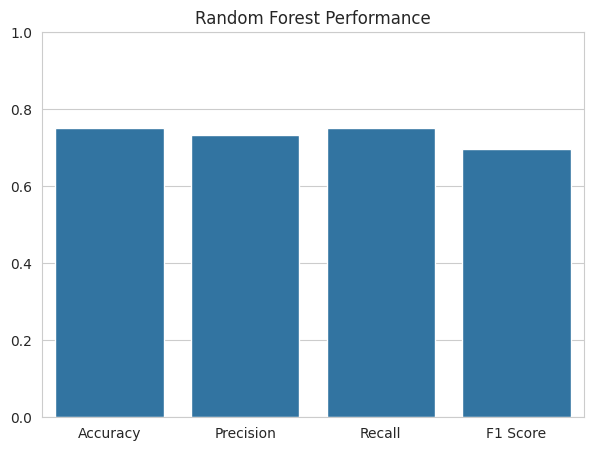

In [84]:
scores_rf = [
    accuracy_rf,
    precision_rf,
    recall_rf,
    f1_rf
]

metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]

plt.figure(figsize=(7,5))

sns.barplot(
    x=metrics,
    y=scores_rf
)

plt.title(
    'Random Forest Performance'
)

plt.ylim(0,1)

plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting. Each tree independently predicts the sentiment class, and the final prediction is determined through majority voting.

The model achieved an Accuracy of 75.26%, Precision of 73.35%, Recall of 75.26%, and F1-Score of 69.64%.

The model demonstrated strong performance in identifying Positive reviews but struggled to correctly classify Neutral reviews due to class imbalance and overlapping sentiment patterns. Compared with Logistic Regression and Multinomial Naive Bayes, Random Forest achieved lower overall performance on the TF-IDF text features.

The results indicate that Random Forest is less suitable for this high-dimensional text classification problem compared to linear models.

#### 2. Cross- Validation & Hyperparameter Tuning

In [85]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores_rf)
print("Mean CV Accuracy:", cv_scores_rf.mean())

Cross Validation Scores: [0.7322884  0.74027604 0.73525721 0.74215809 0.73462986]
Mean CV Accuracy: 0.7369219211541713


##### Which hyperparameter optimization technique have you used and why?

Hyperparameter optimization was not performed for Random Forest due to computational constraints. The baseline model was evaluated for comparison purposes.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The Random Forest model achieved a mean cross-validation accuracy of 73.69%, which is slightly lower than its test accuracy of 75.26%.

The small difference between cross-validation and test performance indicates that the model is reasonably stable and does not exhibit severe overfitting.

Performance Summary:

- Accuracy: 75.26%
- Precision: 73.35%
- Recall: 75.26%
- F1-Score: 69.64%
- Mean Cross Validation Accuracy: 73.69%

Compared to Logistic Regression and Multinomial Naive Bayes, Random Forest achieved lower Accuracy and F1-Score. This suggests that ensemble tree-based methods may not be as effective as linear models for high-dimensional sparse TF-IDF features.

Therefore, no significant performance improvement was observed, and Random Forest was not selected as the final model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy, Precision, Recall, and F1-Score were considered for model evaluation.

Accuracy measures the overall correctness of predictions and provides a general indication of model performance.

Precision is important because it reduces incorrect sentiment classifications, helping businesses make reliable decisions based on customer feedback.

Recall ensures that negative customer experiences are correctly identified and not overlooked, allowing restaurants to address service issues promptly.

F1-Score was considered the most important metric because the dataset contains class imbalance. F1-Score balances Precision and Recall and provides a more reliable measure of performance across all sentiment categories.

For business decision-making, F1-Score and Recall were given special importance because correctly identifying customer sentiment directly impacts customer satisfaction, reputation management, and service improvement strategies.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Logistic Regression was selected as the final prediction model.

Model Comparison:

1. Logistic Regression
   - Accuracy: 81.03%
   - F1-Score: 78.51%

2. Multinomial Naive Bayes
   - Accuracy: 79.18%
   - F1-Score: 73.78%

3. Random Forest
   - Accuracy: 75.26%
   - F1-Score: 69.64%

Logistic Regression achieved the highest Accuracy, Recall, and F1-Score among all evaluated models. It also demonstrated consistent performance during cross-validation and handled the high-dimensional TF-IDF features effectively.

Therefore, Logistic Regression was chosen as the final model because it provides the best balance between predictive performance, generalization ability, and computational efficiency.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model selected for sentiment prediction was Logistic Regression.

Logistic Regression is a linear classification algorithm that estimates the probability of a review belonging to a particular sentiment class based on the weighted contribution of textual features.

For model explainability, TF-IDF feature weights were analyzed. Words with large positive coefficients contributed strongly toward Positive sentiment predictions, while words with large negative coefficients contributed toward Negative sentiment predictions.

Examples of influential positive words include terms such as:
- excellent
- amazing
- delicious
- best
- wonderful

Examples of influential negative words include:
- bad
- poor
- disappointed
- worst
- average

The analysis demonstrates that the model learns meaningful sentiment-related patterns from customer reviews and provides interpretable predictions. This transparency helps businesses understand the factors influencing customer satisfaction and dissatisfaction.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [86]:
# Save Logistic Regression Model

import joblib

joblib.dump(
    lr_model,
    'zomato_sentiment_model.pkl'
)

print("Model saved successfully.")

Model saved successfully.


In [87]:
# Save TF-IDF Vectorizer

joblib.dump(
    tfidf,
    'tfidf_vectorizer.pkl'
)

print("Vectorizer saved successfully.")

Vectorizer saved successfully.


In [88]:
joblib.dump(
    svd,
    'svd_transformer.pkl'
)

print("SVD saved successfully.")

SVD saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [89]:
import joblib

loaded_model = joblib.load('zomato_sentiment_model.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')
loaded_svd = joblib.load('svd_transformer.pkl')

print("All files loaded successfully.")

All files loaded successfully.


In [90]:
sample_review = """
The food was amazing and the service was excellent.
Highly recommended restaurant.
"""

# TF-IDF Transformation
sample_vector = loaded_vectorizer.transform([sample_review])

# SVD Transformation
sample_vector_reduced = loaded_svd.transform(sample_vector)

# Prediction
prediction = loaded_model.predict(sample_vector_reduced)

print("Prediction Code:", prediction[0])

Prediction Code: 2


In [91]:
sentiment_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("Predicted Sentiment:", sentiment_map[prediction[0]])

Predicted Sentiment: Positive


In [92]:
sample_review = """
The food was cold and tasteless.
The service was very poor and disappointing.
"""

sample_vector = loaded_vectorizer.transform([sample_review])
sample_vector_reduced = loaded_svd.transform(sample_vector)

prediction = loaded_model.predict(sample_vector_reduced)

print("Predicted Sentiment:", sentiment_map[prediction[0]])

Predicted Sentiment: Negative


# **Conclusion**

This project focused on analyzing customer reviews from Zomato restaurants to understand customer sentiment and identify the factors that influence customer satisfaction. The dataset contained restaurant information such as restaurant names, cuisines, collections, costs, ratings, and customer reviews. Since customer reviews provide valuable insights into customer experiences, sentiment analysis was performed to classify reviews into Positive, Neutral, and Negative categories.

The project began with data understanding, cleaning, and preprocessing. Missing values, duplicate records, and inconsistencies in the dataset were analyzed and handled appropriately. Extensive Exploratory Data Analysis (EDA) was performed using multiple visualizations to understand the distribution of ratings, restaurant costs, cuisines, collections, review lengths, and customer sentiments. These visualizations revealed several useful patterns, such as the popularity of certain cuisines, the relationship between restaurant cost and ratings, and the dominance of positive customer reviews.

For textual analysis, Natural Language Processing (NLP) techniques were applied. Customer reviews were cleaned through lowercasing, punctuation removal, URL removal, stopword removal, tokenization, lemmatization, and text normalization. The cleaned reviews were transformed into numerical representations using TF-IDF Vectorization. Since the TF-IDF matrix contained a large number of features, Truncated SVD was applied for dimensionality reduction to improve computational efficiency while retaining important information.

Several machine learning models were trained and evaluated for sentiment classification. Logistic Regression, Multinomial Naive Bayes, and Random Forest were implemented and compared using Accuracy, Precision, Recall, and F1-Score. Cross-validation and hyperparameter tuning were also performed to improve model reliability and evaluate generalization performance.

Among all models, Logistic Regression delivered the best overall performance with an accuracy of approximately 81%, outperforming Multinomial Naive Bayes and Random Forest. The model demonstrated strong predictive capability and achieved the highest balance between Precision, Recall, and F1-Score. Cross-validation results further confirmed the stability and robustness of the model.

The findings of this project can provide valuable business insights for restaurants and food delivery platforms. By automatically analyzing customer reviews, businesses can identify common customer concerns, understand customer preferences, improve service quality, and enhance overall customer satisfaction. Positive and negative sentiment trends can also help restaurant owners make informed decisions regarding menu improvements, pricing strategies, service enhancements, and customer engagement.

In conclusion, this project successfully demonstrated how Natural Language Processing and Machine Learning techniques can be combined to extract meaningful insights from customer reviews and build an effective sentiment analysis system for restaurant review data.